# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

## Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [5]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
dataframes = {
    'Household Income': df_hh_income,
    'Poverty Rate': df_pct_poverty,
    'Completed HS': df_pct_completed_hs,
    'Share Race City': df_share_race_city,
    'Fatalities': df_fatalities
}

for name, df in dataframes.items():
    print(f"\n--- {name} Dataframe ---")
    print(f"Shape: {df.shape} (rows, columns)")
    print(f"Column Names: {df.columns.tolist()}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print(f"Number of Duplicates: {df.duplicated().sum()}")


--- Household Income Dataframe ---
Shape: (29322, 3) (rows, columns)
Column Names: ['Geographic Area', 'City', 'Median Income']
Missing Values:
Geographic Area     0
City                0
Median Income      51
dtype: int64
Number of Duplicates: 0

--- Poverty Rate Dataframe ---
Shape: (29329, 3) (rows, columns)
Column Names: ['Geographic Area', 'City', 'poverty_rate']
Missing Values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Number of Duplicates: 0

--- Completed HS Dataframe ---
Shape: (29329, 3) (rows, columns)
Column Names: ['Geographic Area', 'City', 'percent_completed_hs']
Missing Values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Number of Duplicates: 0

--- Share Race City Dataframe ---
Shape: (29268, 7) (rows, columns)
Column Names: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
Missing Values:
Geographic area          0
City   

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [8]:
print("--- Starting Data Cleaning ---")

# --- Handling NaN values ---

# 1. For df_pct_poverty and df_pct_completed_hs:
# These dataframes have ' - ' as missing values which should be converted to NaN first
# and then to numeric. Then fill with 0.
print("\n--- Cleaning df_pct_poverty and df_pct_completed_hs (missing values) ---")
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].replace(' - ', np.nan)
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].replace(' - ', np.nan)

df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].fillna(0)
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].fillna(0)

print(f"Missing values in df_pct_poverty['poverty_rate'] after cleaning: {df_pct_poverty['poverty_rate'].isnull().sum()}")
print(f"Missing values in df_pct_completed_hs['percent_completed_hs'] after cleaning: {df_pct_completed_hs['percent_completed_hs'].isnull().sum()}")


# 2. For df_hh_income: 'Median Income'
# Convert 'Median Income' to numeric, as it might contain non-numeric strings, then fill with 0.
print("\n--- Cleaning df_hh_income (missing values) ---")
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(0)
print(f"Missing values in df_hh_income['Median Income'] after cleaning: {df_hh_income['Median Income'].isnull().sum()}")


# 3. For df_fatalities: 'armed', 'age', 'race', 'flee'
# 'armed', 'race', 'flee' are categorical. Fill with 'Unknown'.
# 'age' is numerical. Fill with 0.
print("\n--- Cleaning df_fatalities (missing values) ---")
df_fatalities['armed'] = df_fatalities['armed'].fillna('Unknown')
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')
df_fatalities['flee'] = df_fatalities['flee'].fillna('Unknown')
df_fatalities['age'] = df_fatalities['age'].fillna(0)

print(f"Missing values in df_fatalities['armed'] after cleaning: {df_fatalities['armed'].isnull().sum()}")
print(f"Missing values in df_fatalities['age'] after cleaning: {df_fatalities['age'].isnull().sum()}")
print(f"Missing values in df_fatalities['race'] after cleaning: {df_fatalities['race'].isnull().sum()}")
print(f"Missing values in df_fatalities['flee'] after cleaning: {df_fatalities['flee'].isnull().sum()}")

print("\n--- All DataFrames have been cleaned of NaN values. ---")

# --- Checking and Dropping Duplicates ---
print("\n--- Checking for and dropping duplicates ---")
dataframes_to_check = {
    'Household Income': df_hh_income,
    'Poverty Rate': df_pct_poverty,
    'Completed HS': df_pct_completed_hs,
    'Share Race City': df_share_race_city,
    'Fatalities': df_fatalities
}

for name, df_obj in dataframes_to_check.items():
    initial_rows = df_obj.shape[0]
    df_obj.drop_duplicates(inplace=True)
    rows_after_dropping = df_obj.shape[0]
    if initial_rows > rows_after_dropping:
        print(f"{name}: Dropped {initial_rows - rows_after_dropping} duplicate rows.")
    else:
        print(f"{name}: No duplicate rows found.")

print("\n--- Data Cleaning Complete! ---")

--- Starting Data Cleaning ---

--- Cleaning df_pct_poverty and df_pct_completed_hs (missing values) ---
Missing values in df_pct_poverty['poverty_rate'] after cleaning: 0
Missing values in df_pct_completed_hs['percent_completed_hs'] after cleaning: 0

--- Cleaning df_hh_income (missing values) ---
Missing values in df_hh_income['Median Income'] after cleaning: 0

--- Cleaning df_fatalities (missing values) ---
Missing values in df_fatalities['armed'] after cleaning: 0
Missing values in df_fatalities['age'] after cleaning: 0
Missing values in df_fatalities['race'] after cleaning: 0
Missing values in df_fatalities['flee'] after cleaning: 0

--- All DataFrames have been cleaned of NaN values. ---

--- Checking for and dropping duplicates ---
Household Income: No duplicate rows found.
Poverty Rate: No duplicate rows found.
Completed HS: No duplicate rows found.
Share Race City: No duplicate rows found.
Fatalities: No duplicate rows found.

--- Data Cleaning Complete! ---


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [11]:
# Group by 'Geographic Area' (state) and calculate the mean poverty rate
poverty_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)

# Convert to a DataFrame for Plotly Express
poverty_by_state_df = poverty_by_state.reset_index()
poverty_by_state_df.columns = ['State', 'Poverty Rate']

# Create the bar chart using Plotly Express
fig = px.bar(
    poverty_by_state_df,
    x='State',
    y='Poverty Rate',
    title='Average Poverty Rate by US State (Highest to Lowest)',
    labels={'Poverty Rate': 'Average Poverty Rate (%)'},
    color='Poverty Rate', # Color bars based on poverty rate
    color_continuous_scale=px.colors.sequential.Plasma
)

fig.update_layout(xaxis_title='US State', yaxis_title='Average Poverty Rate (%)')
fig.show()

# Identify the state with the highest and lowest poverty rate
highest_poverty_state = poverty_by_state_df.iloc[0]
lowest_poverty_state = poverty_by_state_df.iloc[-1]

print(f"\nThe state with the highest poverty rate is {highest_poverty_state['State']} with an average of {highest_poverty_state['Poverty Rate']:.2f}%.")
print(f"The state with the lowest poverty rate is {lowest_poverty_state['State']} with an average of {lowest_poverty_state['Poverty Rate']:.2f}%.")


The state with the highest poverty rate is MS with an average of 26.88%.
The state with the lowest poverty rate is NJ with an average of 8.16%.


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [12]:
# Group by 'Geographic Area' (state) and calculate the mean high school completion rate
hs_completion_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=True)

# Convert to a DataFrame for Plotly Express
hs_completion_by_state_df = hs_completion_by_state.reset_index()
hs_completion_by_state_df.columns = ['State', 'High School Graduation Rate']

# Create the bar chart using Plotly Express
fig = px.bar(
    hs_completion_by_state_df,
    x='State',
    y='High School Graduation Rate',
    title='Average High School Graduation Rate by US State (Lowest to Highest)',
    labels={'High School Graduation Rate': 'Average High School Graduation Rate (%)'},
    color='High School Graduation Rate', # Color bars based on graduation rate
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.update_layout(xaxis_title='US State', yaxis_title='Average High School Graduation Rate (%)')
fig.show()

# Identify the state with the lowest and highest high school graduation rate
lowest_hs_state = hs_completion_by_state_df.iloc[0]
highest_hs_state = hs_completion_by_state_df.iloc[-1]

print(f"\nThe state with the lowest high school graduation rate is {lowest_hs_state['State']} with an average of {lowest_hs_state['High School Graduation Rate']:.2f}%.")
print(f"The state with the highest high school graduation rate is {highest_hs_state['State']} with an average of {highest_hs_state['High School Graduation Rate']:.2f}%.")


The state with the lowest high school graduation rate is TX with an average of 74.09%.
The state with the highest high school graduation rate is MA with an average of 92.03%.


# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [14]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Merge the two dataframes on 'State'
merged_df = pd.merge(poverty_by_state_df, hs_completion_by_state_df, on='State')

# Sort by poverty rate for consistent ordering on the x-axis
merged_df.sort_values('Poverty Rate', ascending=False, inplace=True)

# Create a figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter(x=merged_df['State'], y=merged_df['Poverty Rate'], name='Poverty Rate', mode='lines+markers'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=merged_df['State'], y=merged_df['High School Graduation Rate'], name='High School Graduation Rate', mode='lines+markers'),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text="Poverty Rate vs. High School Graduation Rate by US State"
)

# Set x-axis title
fig.update_xaxes(title_text="US State")

# Set y-axes titles
fig.update_yaxes(title_text="<b>Poverty Rate (%)</b>", secondary_y=False)
fig.update_yaxes(title_text="<b>High School Graduation Rate (%)</b>", secondary_y=True)

fig.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

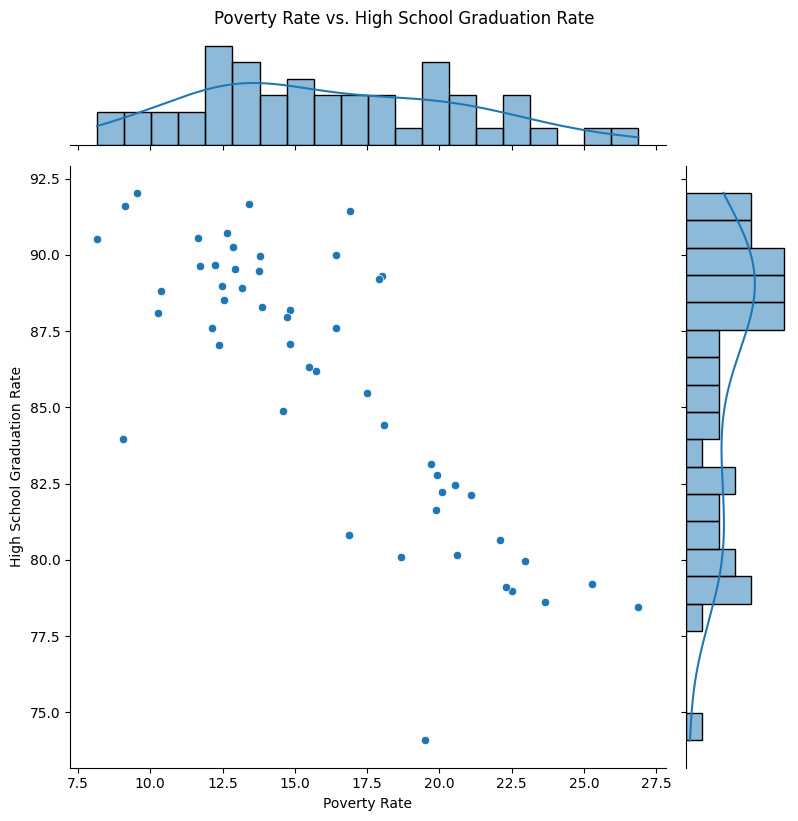

In [16]:
sns.jointplot(x='Poverty Rate', y='High School Graduation Rate', data=merged_df, kind='scatter', height=8, marginal_kws=dict(bins=20, kde=True))
plt.suptitle('Poverty Rate vs. High School Graduation Rate', y=1.02) # Add a suptitle to avoid overlap
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

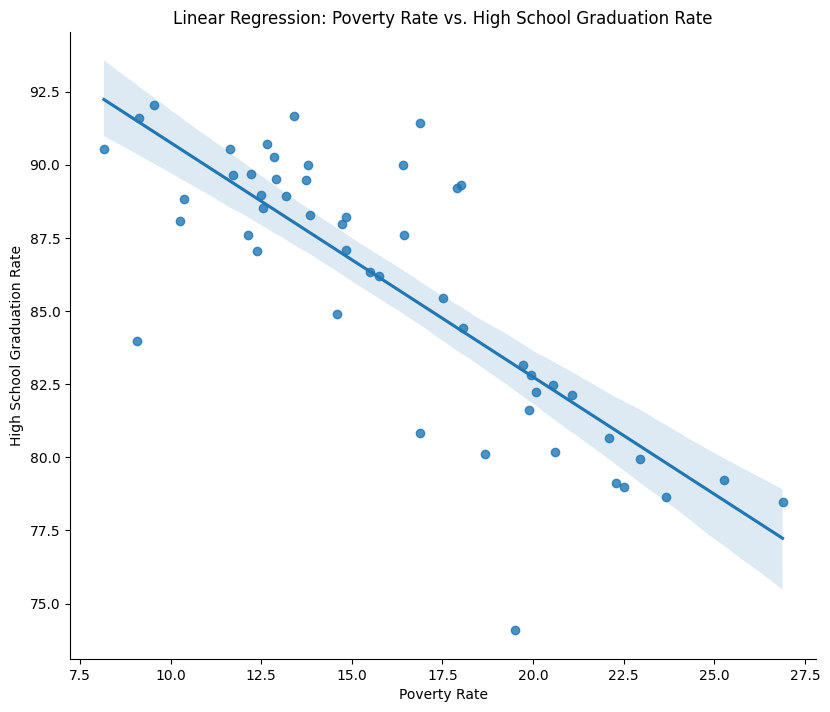

In [18]:
sns.lmplot(x='Poverty Rate', y='High School Graduation Rate', data=merged_df, height=7, aspect=1.2)
plt.title('Linear Regression: Poverty Rate vs. High School Graduation Rate')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [20]:
# Convert racial share columns to numeric, coercing errors to NaN
for col in ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')
    # Fill any NaNs that resulted from coercion with 0, assuming 0 share if data is missing
    df_share_race_city[col] = df_share_race_city[col].fillna(0)

# Group by 'Geographic area' (state) and calculate the mean share for each race
racial_makeup_by_state = df_share_race_city.groupby('Geographic area')[['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']].mean().reset_index()

# Rename the 'Geographic area' column to 'State'
racial_makeup_by_state.rename(columns={'Geographic area': 'State'}, inplace=True);

# Melt the DataFrame to long format for Plotly Express stacked bar chart
racial_makeup_melted = racial_makeup_by_state.melt(id_vars=['State'],
                                                  var_name='Race',
                                                  value_name='Share')

# Map the column names to more readable race names
race_name_map = {
    'share_white': 'White',
    'share_black': 'Black',
    'share_native_american': 'Native American',
    'share_asian': 'Asian',
    'share_hispanic': 'Hispanic'
}
racial_makeup_melted['Race'] = racial_makeup_melted['Race'].map(race_name_map)

# Create the stacked bar chart using Plotly Express
fig = px.bar(
    racial_makeup_melted,
    x='State',
    y='Share',
    color='Race',
    title='Racial Makeup of Each US State',
    labels={'Share': 'Share of Population (%)', 'State': 'US State'},
    barmode='stack', # This ensures the bars are stacked
    color_discrete_map={
        'White': 'lightgray',
        'Black': 'darkgray',
        'Native American': 'brown',
        'Asian': 'orange',
        'Hispanic': 'red'
    }
)

fig.update_layout(xaxis_title='US State', yaxis_title='Share of Population (%)')
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [22]:
# Calculate the number of fatalities by gender
gender_counts = df_fatalities['gender'].value_counts()

# Create a bar chart using Plotly Express
fig = px.bar(
    x=gender_counts.index,
    y=gender_counts.values,
    title='Total Number of Deaths by Gender',
    labels={'x': 'Gender', 'y': 'Number of Deaths'},
    color=gender_counts.index,
    color_discrete_map={'M': 'blue', 'F': 'pink'}
)

fig.update_layout(xaxis_title='Gender', yaxis_title='Number of Deaths')
fig.show()

# Calculate the difference between men and women fatalities
men_killed = gender_counts.get('M', 0)
women_killed = gender_counts.get('F', 0)

difference = men_killed - women_killed

print(f"\nTotal men killed: {men_killed}")
print(f"Total women killed: {women_killed}")
print(f"Men were killed {difference} more times than women.")


Total men killed: 2428
Total women killed: 107
Men were killed 2321 more times than women.


# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [23]:
# Filter out ages that were filled with 0 (missing values)
df_fatalities_filtered_age = df_fatalities[df_fatalities['age'] > 0]

# Create the box plot using Plotly Express
fig = px.box(
    df_fatalities_filtered_age,
    x='manner_of_death',
    y='age',
    color='gender',
    title='Age Distribution by Manner of Death and Gender',
    labels={'manner_of_death': 'Manner of Death', 'age': 'Age', 'gender': 'Gender'},
    category_orders={'gender': ['M', 'F']}, # Ensure consistent order for genders
)

fig.update_layout(xaxis_title='Manner of Death', yaxis_title='Age')
fig.show()

print("\nBased on the box plot, we can observe the age distribution for different manners of death, broken down by gender. Look for differences in median age (the line inside the box), the spread of ages (the box itself), and outliers (individual points) between male and female populations within each manner of death category to see if there's a difference.")


Based on the box plot, we can observe the age distribution for different manners of death, broken down by gender. Look for differences in median age (the line inside the box), the spread of ages (the box itself), and outliers (individual points) between male and female populations within each manner of death category to see if there's a difference.


# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [24]:
# 1. Get the counts of each 'armed' category
armed_counts = df_fatalities['armed'].value_counts()

# 2. Calculate the total number of fatalities
total_fatalities = df_fatalities.shape[0]

# 3. Calculate the percentage of people who were armed
# Exclude 'Unarmed' and 'Unknown' from the armed count
armed_excluding_unarmed_unknown = armed_counts[~armed_counts.index.isin(['unarmed', 'Unknown'])].sum()
percentage_armed = (armed_excluding_unarmed_unknown / total_fatalities) * 100

print(f"Total fatalities: {total_fatalities}")
print(f"Number of people confirmed armed (excluding 'unarmed' and 'Unknown'): {armed_excluding_unarmed_unknown}")
print(f"Percentage of people killed who were confirmed armed: {percentage_armed:.2f}%")

# 4. Create a chart to show what kind of weapon (if any) the deceased was carrying
fig_armed = px.bar(
    x=armed_counts.index,
    y=armed_counts.values,
    title='Types of Weapons Carried by Deceased',
    labels={'x': 'Armed Status', 'y': 'Number of Fatalities'},
    color=armed_counts.index,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig_armed.update_layout(xaxis_title='Armed Status', yaxis_title='Number of Fatalities')
fig_armed.show()

# 5. How many of the people killed by police were armed with guns versus unarmed?
guns_armed = armed_counts.get('gun', 0) + armed_counts.get('toy weapon', 0) + armed_counts.get('airsoft gun', 0) + armed_counts.get('BB gun', 0) + armed_counts.get('replica gun', 0)
unarmed = armed_counts.get('unarmed', 0)

print(f"\nNumber of people armed with a gun (including toy/replica guns): {guns_armed}")
print(f"Number of people unarmed: {unarmed}")

Total fatalities: 2535
Number of people confirmed armed (excluding 'unarmed' and 'Unknown'): 2355
Percentage of people killed who were confirmed armed: 92.90%



Number of people armed with a gun (including toy/replica guns): 1502
Number of people unarmed: 171


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [25]:
# Filter out records where age is 0 (missing age) before analysis
df_fatalities_actual_age = df_fatalities[df_fatalities['age'] > 0]

# Calculate the number of people under 25 years old
under_25_killed = df_fatalities_actual_age[df_fatalities_actual_age['age'] < 25].shape[0]

# Calculate the total number of fatalities with known age
total_fatalities_known_age = df_fatalities_actual_age.shape[0]

# Calculate the percentage
percentage_under_25 = (under_25_killed / total_fatalities_known_age) * 100

print(f"Total fatalities with known age: {total_fatalities_known_age}")
print(f"Number of people killed under 25 years old: {under_25_killed}")
print(f"Percentage of people killed who were under 25 years old: {percentage_under_25:.2f}%")

Total fatalities with known age: 2458
Number of people killed under 25 years old: 450
Percentage of people killed who were under 25 years old: 18.31%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

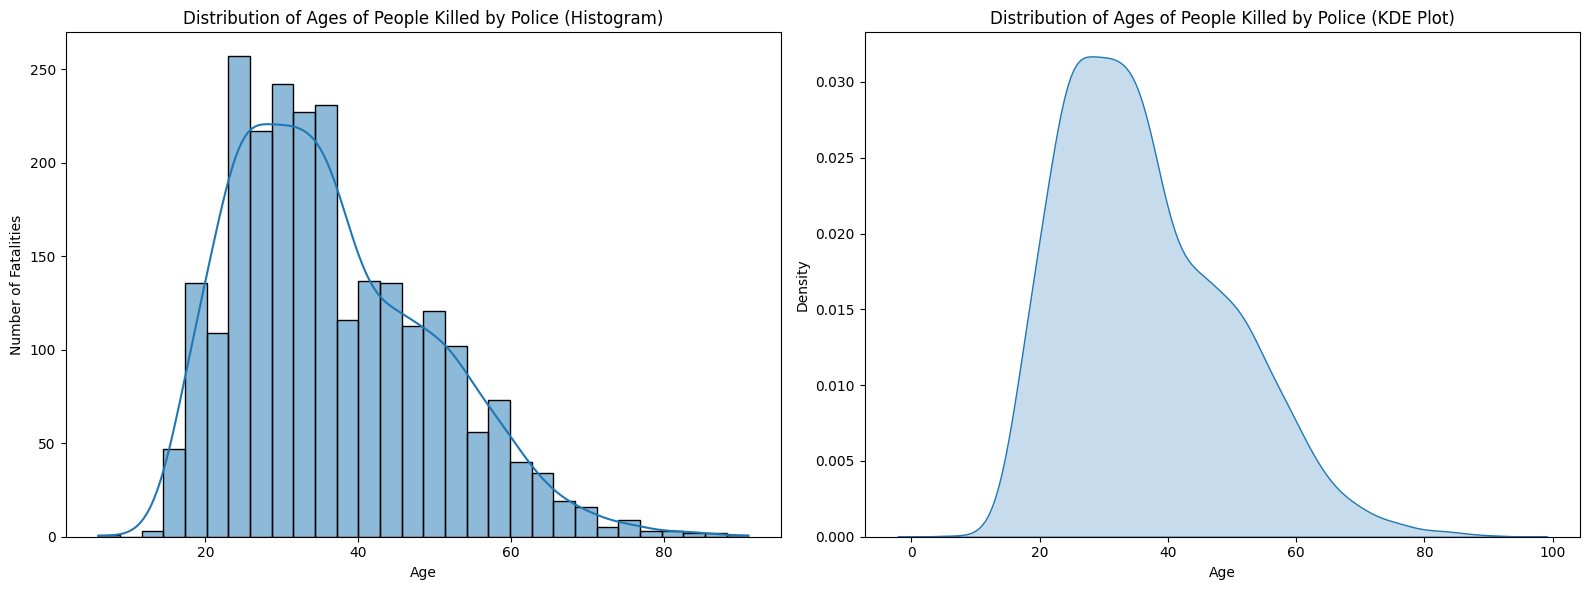

In [27]:
# Create a figure with two subplots for histogram and KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df_fatalities_actual_age['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Ages of People Killed by Police (Histogram)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Fatalities')

# KDE Plot
sns.kdeplot(df_fatalities_actual_age['age'], fill=True, ax=axes[1])
axes[1].set_title('Distribution of Ages of People Killed by Police (KDE Plot)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

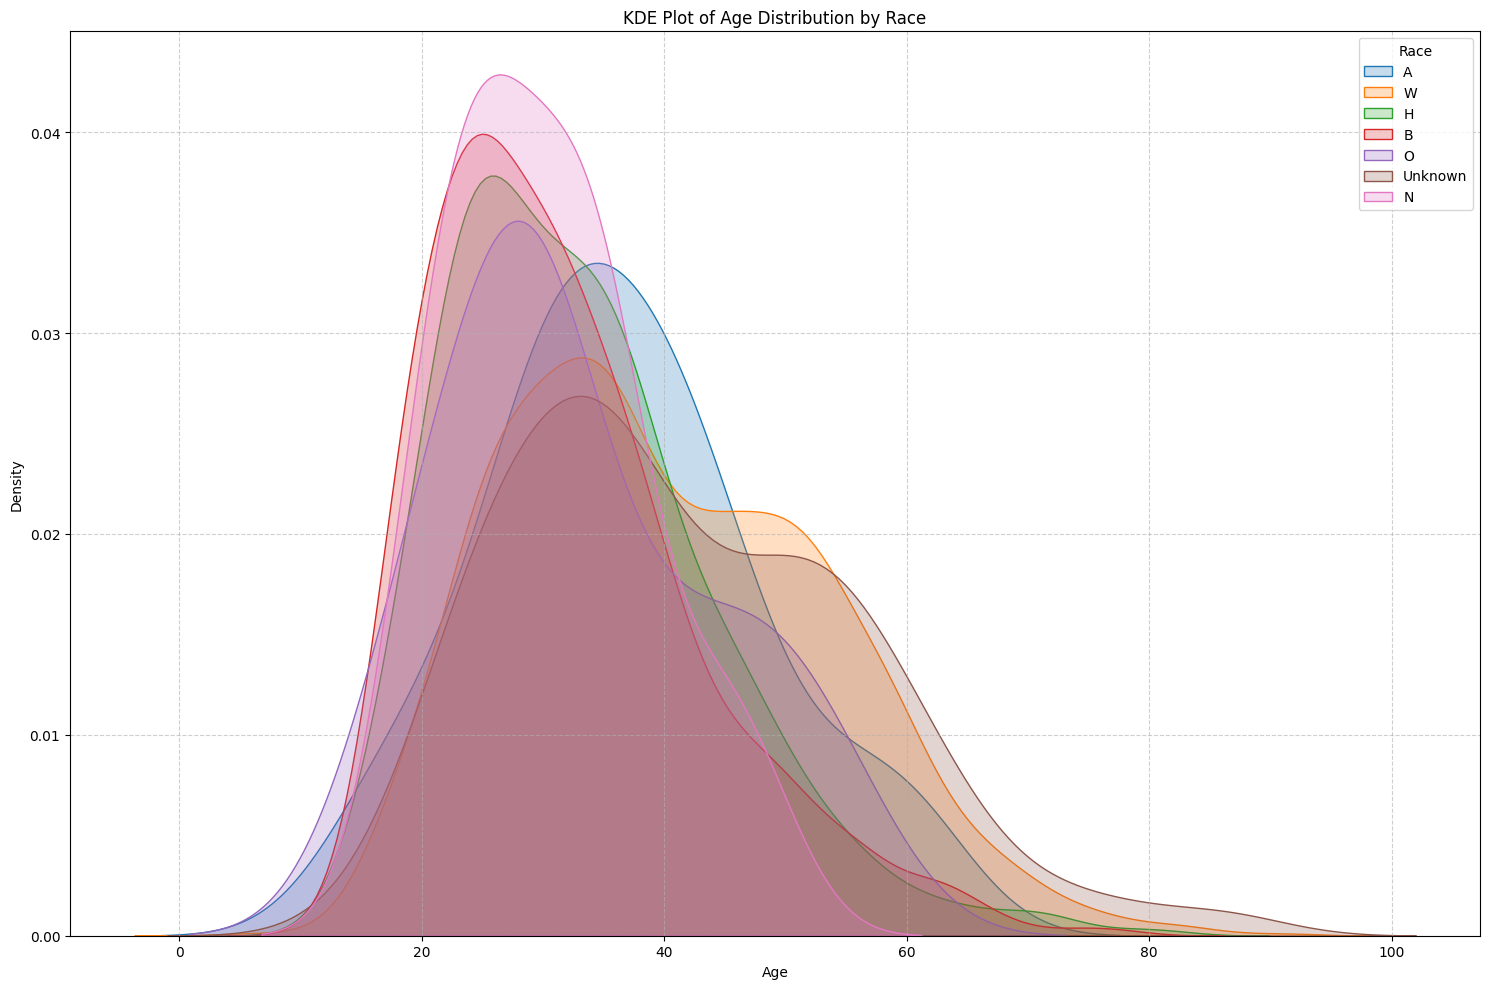

Observe the KDE plots above. Look for differences in the peaks (most common age), the spread (age range), and the overall shape of the curves for each racial group to determine if there's a difference in their age distributions.


In [28]:
# Get unique races from the filtered fatalities data
unique_races = df_fatalities_actual_age['race'].unique()

plt.figure(figsize=(15, 10))
for race in unique_races:
    # Filter data for the current race
    race_data = df_fatalities_actual_age[df_fatalities_actual_age['race'] == race]
    if not race_data.empty:
        sns.kdeplot(race_data['age'], label=race, fill=True)

plt.title('KDE Plot of Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Race')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Observe the KDE plots above. Look for differences in the peaks (most common age), the spread (age range), and the overall shape of the curves for each racial group to determine if there's a difference in their age distributions.")

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [29]:
# Calculate the total number of people killed by race
race_counts = df_fatalities['race'].value_counts().reset_index()
race_counts.columns = ['Race', 'Number of Fatalities']

# Create a bar chart using Plotly Express
fig = px.bar(
    race_counts,
    x='Race',
    y='Number of Fatalities',
    title='Total Number of People Killed by Race',
    labels={'Race': 'Race', 'Number of Fatalities': 'Number of Fatalities'},
    color='Race', # Color bars by race for better distinction
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(xaxis_title='Race', yaxis_title='Number of Fatalities')
fig.show()

print("Total number of people killed by race:")
print(race_counts)

Total number of people killed by race:
      Race  Number of Fatalities
0        W                  1201
1        B                   618
2        H                   423
3  Unknown                   195
4        A                    39
5        N                    31
6        O                    28


# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [30]:
# Calculate the number of people with signs of mental illness
mental_illness_count = df_fatalities[df_fatalities['signs_of_mental_illness'] == True].shape[0]

# Calculate the total number of fatalities
total_fatalities = df_fatalities.shape[0]

# Calculate the percentage
percentage_mental_illness = (mental_illness_count / total_fatalities) * 100

print(f"Total fatalities: {total_fatalities}")
print(f"Number of people with signs of mental illness: {mental_illness_count}")
print(f"Percentage of people killed by police with signs of mental illness: {percentage_mental_illness:.2f}%")

Total fatalities: 2535
Number of people with signs of mental illness: 633
Percentage of people killed by police with signs of mental illness: 24.97%


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [31]:
# Calculate the number of police killings per city
city_killings = df_fatalities['city'].value_counts()

# Get the top 10 cities with the most police killings
top_10_cities = city_killings.head(10).reset_index()
top_10_cities.columns = ['City', 'Number of Killings']

# Create a bar chart for the top 10 cities
fig = px.bar(
    top_10_cities,
    x='City',
    y='Number of Killings',
    title='Top 10 Cities with Most Police Killings',
    labels={'City': 'City', 'Number of Killings': 'Number of Police Killings'},
    color='Number of Killings',
    color_continuous_scale=px.colors.sequential.Reds
)

fig.update_layout(xaxis_title='City', yaxis_title='Number of Police Killings')
fig.show()

print("\nThe cities with the most police killings are:")
for index, row in top_10_cities.iterrows():
    print(f"{row['City']}: {row['Number of Killings']} killings")


The cities with the most police killings are:
Los Angeles: 39 killings
Phoenix: 31 killings
Houston: 27 killings
Chicago: 25 killings
Las Vegas: 21 killings
San Antonio: 20 killings
Columbus: 19 killings
Miami: 18 killings
Austin: 18 killings
St. Louis: 15 killings


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [35]:
import pandas as pd

# Helper function for cleaning city names (re-defined for clarity in this step)
def clean_city_name(city):
    if isinstance(city, str):
        city = city.replace(' city', '').replace(' town', '').replace(' CDP', '').replace(' Census Designated Place', '').strip().lower()
    return city

# --- Re-determine the exact top 10 city_state combinations based on total killings ---
# This uses the original df_fatalities to precisely identify the top 10 cities by unique city-state combination

df_fatalities_cleaned = df_fatalities.copy()
df_fatalities_cleaned['cleaned_city'] = df_fatalities_cleaned['city'].apply(clean_city_name)
df_fatalities_cleaned['city_state_combined'] = df_fatalities_cleaned['cleaned_city'] + ', ' + df_fatalities_cleaned['state']

# Calculate total killings per unique city_state_combined
total_killings_per_city_state = df_fatalities_cleaned['city_state_combined'].value_counts().reset_index()
total_killings_per_city_state.columns = ['city_state', 'Total Killings']

# Get the actual top 10 city_state combinations
actual_top_10_city_states = total_killings_per_city_state.head(10)['city_state'].tolist()

print(f"Actual Top 10 city_states for disparity analysis: {actual_top_10_city_states}")

# --- Filter racial_population_proportions for actual_top_10_city_states ---
racial_population_proportions_filtered = racial_population_proportions[
    racial_population_proportions['city_state'].isin(actual_top_10_city_states)
].copy()

# --- Filter killings_by_city_race_counts for actual_top_10_city_states ---
killings_by_city_race_counts_filtered = killings_by_city_race_counts[
    killings_by_city_race_counts['city_state'].isin(actual_top_10_city_states)
].copy()

print("\n--- Racial Population Proportions (filtered, first 5 rows) ---")
print(racial_population_proportions_filtered.head())
print(f"Number of unique city_states in filtered racial_population_proportions: {racial_population_proportions_filtered['city_state'].nunique()}")

print("\n--- Killings Proportions by City and Race (filtered, first 5 rows) ---")
print(killings_by_city_race_counts_filtered.head())
print(f"Number of unique city_states in filtered killings_by_city_race_counts: {killings_by_city_race_counts_filtered['city_state'].nunique()}")

# --- Merge the two filtered DataFrames ---
# Merge on 'city_state' and 'Race'
disparity_df = pd.merge(
    racial_population_proportions_filtered,
    killings_by_city_race_counts_filtered,
    on=['city_state', 'Race'],
    how='left'
)

# Fill any NaN values in 'Killing Proportion' with 0 (if a race had no killings in a city)
disparity_df['Killing Proportion'] = disparity_df['Killing Proportion'].fillna(0)

# Calculate the disparity ratio
# Add a small epsilon to Population Share to avoid division by zero for races with 0 population share
epsilon = 1e-6
disparity_df['Disparity Ratio'] = disparity_df['Killing Proportion'] / (disparity_df['Population Share'] + epsilon)

print("\n--- Disparity DataFrame (first 5 rows) ---")
print(disparity_df.head())


Actual Top 10 city_states for disparity analysis: ['los angeles, CA', 'phoenix, AZ', 'houston, TX', 'chicago, IL', 'las vegas, NV', 'san antonio, TX', 'columbus, OH', 'miami, FL', 'austin, TX', 'st. louis, MO']

--- Racial Population Proportions (filtered, first 5 rows) ---
        city_state    Race_Code  Population Share   Race
1      phoenix, AZ  share_white              0.66  White
3  los angeles, CA  share_white              0.50  White
4        miami, FL  share_white              0.73  White
5      chicago, IL  share_white              0.45  White
8    st. louis, MO  share_white              0.44  White
Number of unique city_states in filtered racial_population_proportions: 10

--- Killings Proportions by City and Race (filtered, first 5 rows) ---
    city_state race  Killing Counts  Killing Proportion      Race
2   austin, TX    B               3                0.19     Black
3   austin, TX    H               2                0.12  Hispanic
4   austin, TX    W              11   

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

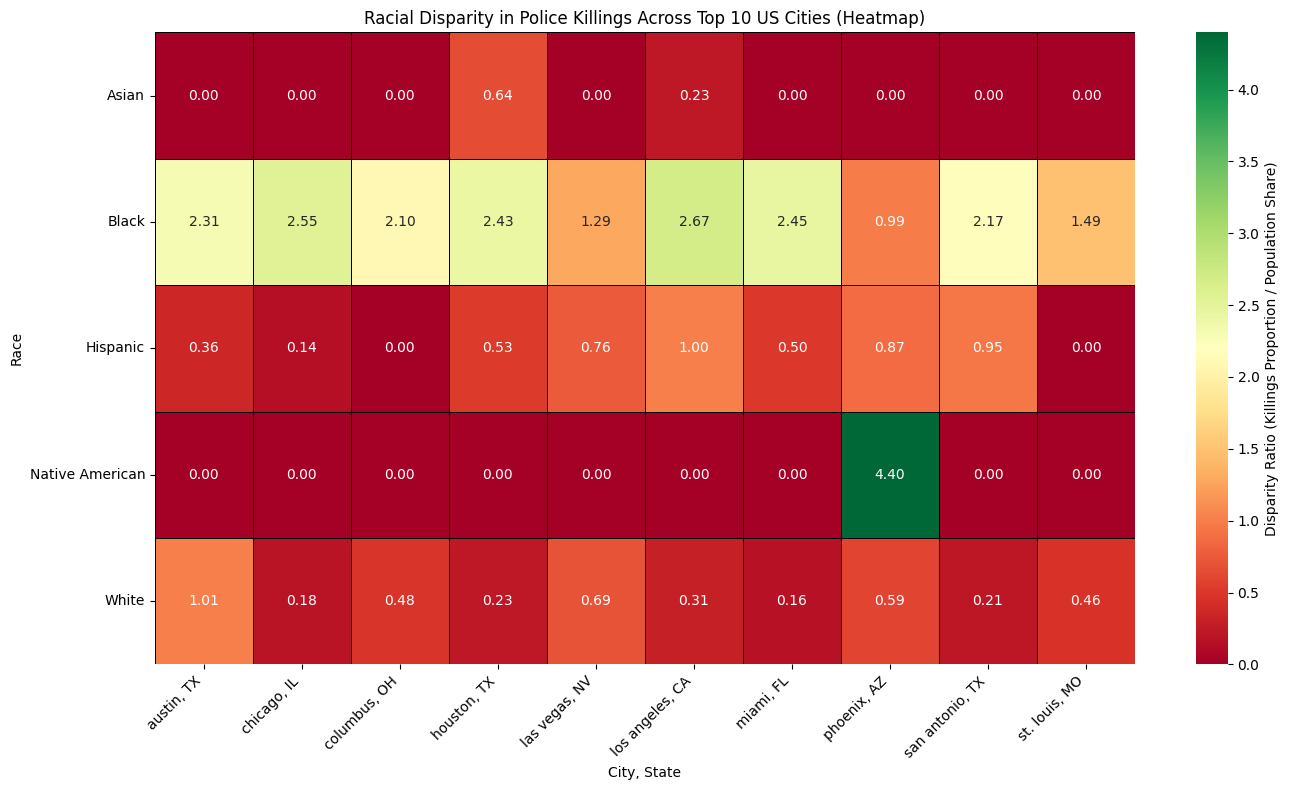

Heatmap of Racial Disparity in Police Killings displayed above. Values greater than 1 indicate overrepresentation in killings relative to population share, while values less than 1 indicate underrepresentation.


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the disparity_df to prepare for heatmap
heatmap_data = disparity_df.pivot_table(
    index='Race',
    columns='city_state',
    values='Disparity Ratio'
)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='RdYlGn', # Red-Yellow-Green colormap, red for high disparity, green for low
    fmt=".2f", # Format annotations to 2 decimal places
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Disparity Ratio (Killings Proportion / Population Share)'}
)

plt.title('Racial Disparity in Police Killings Across Top 10 US Cities (Heatmap)')
plt.xlabel('City, State')
plt.ylabel('Race')
plt.yticks(rotation=0) # Ensure race labels are readable
plt.xticks(rotation=45, ha='right') # Rotate city labels for better readability
plt.tight_layout()
plt.show()

print("Heatmap of Racial Disparity in Police Killings displayed above. Values greater than 1 indicate overrepresentation in killings relative to population share, while values less than 1 indicate underrepresentation.")

In [37]:
import pandas as pd

# 1. Group the df_fatalities DataFrame by the 'state' column and count the number of police killings
state_killings = df_fatalities['state'].value_counts().reset_index()

# 2. Rename the columns for clarity
state_killings.columns = ['state', 'Number of Killings']

print("Total police killings by state:")
print(state_killings.head())

Total police killings by state:
  state  Number of Killings
0    CA                 424
1    TX                 225
2    FL                 154
3    AZ                 118
4    OH                  79


**Reasoning**:
The previous step successfully aggregated the fatalities by state. Now, I will visualize this data using a Plotly Express choropleth map to show the distribution of police killings across US states, as instructed by the main task.



In [38]:
import plotly.express as px

# Create the choropleth map using Plotly Express
fig = px.choropleth(
    state_killings,
    locations='state',
    locationmode='USA-states',
    color='Number of Killings',
    scope='usa',
    color_continuous_scale="Reds",
    title='Number of Police Killings by US State'
)

fig.update_layout(
    geo_scope='usa',
    coloraxis_colorbar_title='Number of Killings'
)

fig.show()

# Identify the states with the highest number of killings
highest_killing_states = state_killings.head(5)
print(f"\nStates with the highest number of police killings:\n{highest_killing_states}")

# Compare with states with high poverty rates (from poverty_by_state_df, previously calculated)
print(f"\nStates with the highest poverty rates (from previous analysis):\n{poverty_by_state_df.head(5)}")

# Compare with states with lowest high school graduation rates (from hs_completion_by_state_df, previously calculated)
print(f"\nStates with the lowest high school graduation rates (from previous analysis):\n{hs_completion_by_state_df.head(5)}")


States with the highest number of police killings:
  state  Number of Killings
0    CA                 424
1    TX                 225
2    FL                 154
3    AZ                 118
4    OH                  79

States with the highest poverty rates (from previous analysis):
  State  Poverty Rate
0    MS         26.88
1    AZ         25.27
2    GA         23.66
3    AR         22.96
4    NM         22.51

States with the lowest high school graduation rates (from previous analysis):
  State  High School Graduation Rate
0    TX                        74.09
1    MS                        78.47
2    GA                        78.63
3    NM                        78.97
4    LA                        79.12
